# Subgroup Analysis by Review Length

This notebook covers the Week 5 subgroup-by-length analysis that was planned in the proposal and called out as a next step in Milestone 2.

Short reviews are a known harder detection setting (Pudasaini et al. 2025, Erol et al. 2025), so even when overall metrics look strong, the detector may be weaker on short text or push more outputs into the uncertain band. The Week 4 to 5 notebook reports overall metrics on the full test set but does not break performance down by review length, so this notebook fills that gap.

We split the test set into short (under 79 words) and long (79 or more words) reviews and compute accuracy, precision, recall, F1, confusion matrices, score separation, and calibration quality for each subgroup. The cutoff matches the `length_group` column already saved in `updated_week4_week5_outputs.pkl` so this analysis stays consistent with the rest of the project.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Dict
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    brier_score_loss,
    log_loss,
)

## 1. Load the saved test predictions

We load `updated_week4_week5_outputs.pkl`, which contains `test_results_df` with the full test-set predictions from the final calibrated random forest, including calibrated AI probabilities, 0 to 100 AI-likeness scores, predicted labels, true labels, word counts, and the existing `length_group` assignment. This means we don't need to re-run feature extraction or reload the raw CSVs.

In [2]:
class TemperatureScalerFit:
    def __init__(self):
        self.temperature = 1.0
    def fit(self, probs, true_labels):
        return self
    def predict_proba(self, probs):
        probs = np.asarray(probs, dtype=float)
        eps = 1e-12
        logits = np.log((probs + eps) / (1 - probs + eps))
        scaled = 1 / (1 + np.exp(-(logits / self.temperature)))
        return np.clip(scaled, 0.0, 1.0)


class ArtifactUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "__main__" and name == "TemperatureScalerFit":
            return TemperatureScalerFit
        return super().find_class(module, name)


OUTPUTS_PATH = "updated_week4_week5_outputs.pkl"

with open(OUTPUTS_PATH, "rb") as f:
    saved = ArtifactUnpickler(f).load()

test_df = saved["test_results_df"].copy()
selected_model_name = saved["selected_model_name"]

print("Selected model:", selected_model_name)
print("Test set size:", len(test_df))
print("Columns:", list(test_df.columns))
print("\nClass distribution:")
print(test_df["true_label"].value_counts())

Selected model: random_forest
Test set size: 5185
Columns: ['review_text', 'model_used', 'calibrated', 'ai_probability', 'ai_likeness_score', 'uncertainty_band', 'predicted_label', 'top_features', 'explanation', 'true_label', 'true_label_binary', 'word_count', 'length_group']

Class distribution:
true_label
Human    4098
AI       1087
Name: count, dtype: int64


## 2. Length subgroup composition

The `length_group` column already partitions the test set at the 79-word boundary (short = under 79 words, long = 79 or more words). This roughly aligns with the boundary between the AI-generation length bands defined in the proposal (short = 40 to 60, medium = 80 to 120, long = 140 to 180), so anything in the short bucket sits in the harder short-text regime that the detector literature flags as a known weakness.

In [3]:
subgroup_summary = (
    test_df.groupby(["length_group", "true_label"]).size().unstack(fill_value=0)
)
subgroup_summary["Total"] = subgroup_summary.sum(axis=1)

print("Word-count range per subgroup:")
print(test_df.groupby("length_group")["word_count"].agg(["min", "max", "mean"]).round(1))
print("\nSubgroup composition (counts):")
subgroup_summary

Word-count range per subgroup:
              min   max   mean
length_group                  
long           79  1458  153.2
short           8    78   49.3

Subgroup composition (counts):


true_label,AI,Human,Total
length_group,,,
long,581,2000,2581
short,506,2098,2604


## 3. Per-subgroup classification metrics

For each subgroup we compute accuracy, precision, recall, F1, and the support count. We treat AI as the positive class so recall directly answers "out of the AI reviews of this length, how many did we catch?" We also include the overall row for reference.

In [4]:
def subgroup_metrics(df_sub: pd.DataFrame) -> Dict[str, float]:
    if df_sub.empty:
        return {"n": 0, "accuracy": np.nan, "precision": np.nan,
                "recall": np.nan, "f1": np.nan}
    y_true = df_sub["true_label_binary"].values
    y_pred = (df_sub["predicted_label"] == "AI").astype(int).values
    acc = accuracy_score(y_true, y_pred)
    if len(np.unique(y_true)) < 2:
        return {"n": len(df_sub), "accuracy": acc,
                "precision": np.nan, "recall": np.nan, "f1": np.nan}
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    return {"n": len(df_sub), "accuracy": acc, "precision": p, "recall": r, "f1": f1}


rows = []
for group_name in ["short", "long"]:
    df_sub = test_df[test_df["length_group"] == group_name]
    metrics = subgroup_metrics(df_sub)
    metrics["length_group"] = group_name
    rows.append(metrics)

overall = subgroup_metrics(test_df)
overall["length_group"] = "all (full test set)"
rows.append(overall)

metrics_df = pd.DataFrame(rows)[
    ["length_group", "n", "accuracy", "precision", "recall", "f1"]
].round(4)
metrics_df

,length_group,n,accuracy,precision,recall,f1
0,short,2604,1.0,1.0,1.0,1.0
1,long,2581,1.0,1.0,1.0,1.0
2,all (full test set),5185,1.0,1.0,1.0,1.0


## 4. Confusion matrices per subgroup

Looking at confusion matrices by subgroup tells us whether errors concentrate in a particular cell. False negatives clustering on short AI reviews (i.e. AI reviews mistakenly labelled human) would mean the model misses AI when text is brief, which is the failure mode the literature warns about most.

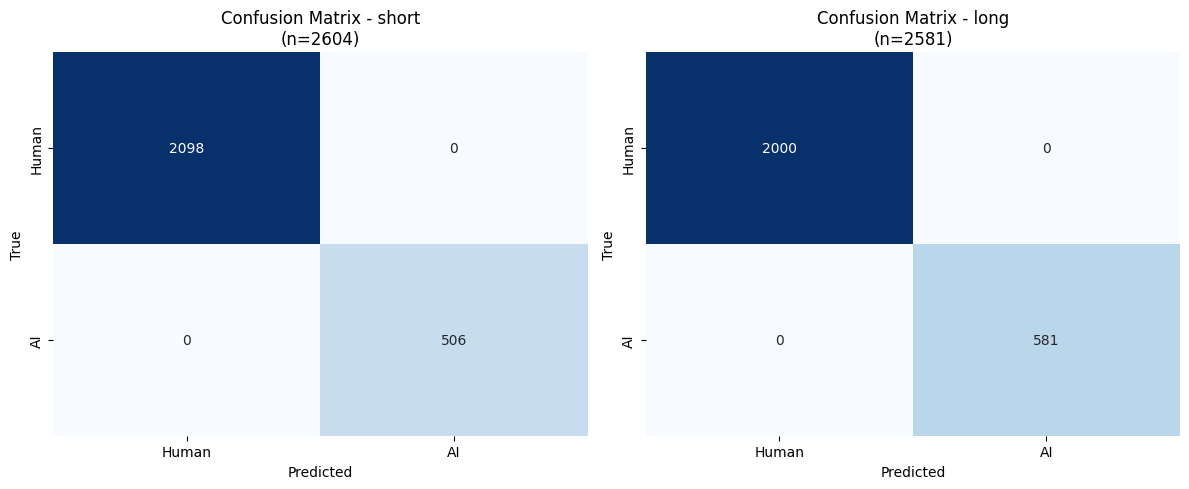

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, group_name in zip(axes, ["short", "long"]):
    df_sub = test_df[test_df["length_group"] == group_name]
    y_true = df_sub["true_label_binary"].values
    y_pred = (df_sub["predicted_label"] == "AI").astype(int).values
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Human", "AI"], yticklabels=["Human", "AI"], cbar=False,
    )
    ax.set_title(f"Confusion Matrix - {group_name}\n(n={len(df_sub)})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## 5. Score separation plots per subgroup

These histograms show how the 0 to 100 AI-likeness score is distributed for true human vs true AI reviews within each subgroup. Strong separation (humans clustered near 0, AI clustered near 100, little overlap in the 40 to 69 uncertain band) is the ideal pattern. If the short subgroup shows more overlap or more mass in the uncertain band, that visually confirms the harder-on-short-text concern.

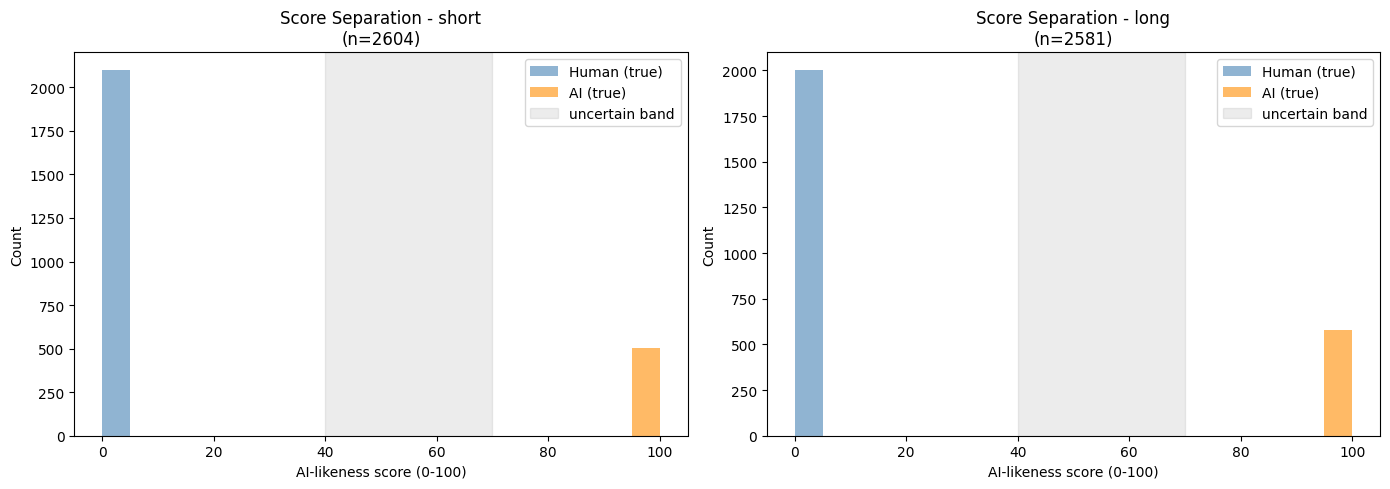

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, group_name in zip(axes, ["short", "long"]):
    df_sub = test_df[test_df["length_group"] == group_name]
    human_scores = df_sub[df_sub["true_label_binary"] == 0]["ai_likeness_score"]
    ai_scores = df_sub[df_sub["true_label_binary"] == 1]["ai_likeness_score"]
    ax.hist(human_scores, bins=20, range=(0, 100), alpha=0.6,
            label="Human (true)", color="steelblue")
    ax.hist(ai_scores, bins=20, range=(0, 100), alpha=0.6,
            label="AI (true)", color="darkorange")
    ax.axvspan(40, 70, color="gray", alpha=0.15, label="uncertain band")
    ax.set_xlabel("AI-likeness score (0-100)")
    ax.set_ylabel("Count")
    ax.set_title(f"Score Separation - {group_name}\n(n={len(df_sub)})")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Uncertain band activation

Milestone 2 noted that the original detector produced zero predictions in the 40 to 69 uncertain band on the full test set. After the diversified-data update, the question is whether the uncertain band starts to activate for shorter reviews specifically, since those are typically harder.

In [7]:
band_table = (
    test_df.groupby(["length_group", "uncertainty_band"]).size()
    .unstack(fill_value=0)
    .reindex(
        columns=["likely human-written", "uncertain", "likely AI-generated"],
        fill_value=0,
    )
)
band_table["total"] = band_table.sum(axis=1)
band_table["% uncertain"] = (
    band_table["uncertain"] / band_table["total"] * 100
).round(3)
band_table

uncertainty_band,likely human-written,uncertain,likely AI-generated,total,% uncertain
length_group,,,,,
long,2000,0,581,2581,0.000
short,2097,1,506,2604,0.038


## 7. Calibration quality per subgroup

Wang et al. (2024) argue that probability outputs should be calibrated before being treated as confidence estimates. Brier score and log loss are standard calibration-aware metrics, where lower values mean predicted probabilities are closer to the true outcome. Comparing them across subgroups tells us whether the calibrated probabilities are equally well-behaved on short and long reviews.

In [8]:
def calibration_quality(df_sub: pd.DataFrame) -> Dict[str, float]:
    if df_sub.empty or len(np.unique(df_sub["true_label_binary"])) < 2:
        return {"n": len(df_sub), "brier": np.nan, "log_loss": np.nan}
    y_true = df_sub["true_label_binary"].values
    probs = df_sub["ai_probability"].clip(1e-7, 1 - 1e-7).values
    return {
        "n": len(df_sub),
        "brier": brier_score_loss(y_true, probs),
        "log_loss": log_loss(y_true, probs, labels=[0, 1]),
    }


calib_rows = []
for group_name in ["short", "long"]:
    df_sub = test_df[test_df["length_group"] == group_name]
    cq = calibration_quality(df_sub)
    cq["length_group"] = group_name
    calib_rows.append(cq)

overall_cq = calibration_quality(test_df)
overall_cq["length_group"] = "all (full test set)"
calib_rows.append(overall_cq)

calib_df = pd.DataFrame(calib_rows)[
    ["length_group", "n", "brier", "log_loss"]
].round(6)
calib_df

,length_group,n,brier,log_loss
0,short,2604,0.000091,0.000257
1,long,2581,0.000000,0.000000
2,all (full test set),5185,0.000046,0.000129


## 8. Word count vs predicted score

A scatter of word count against AI-likeness score makes any length-related drift in the model's confidence visible. If the model genuinely relies on stylistic signal rather than length, the score should not depend strongly on word count within each true-label group.

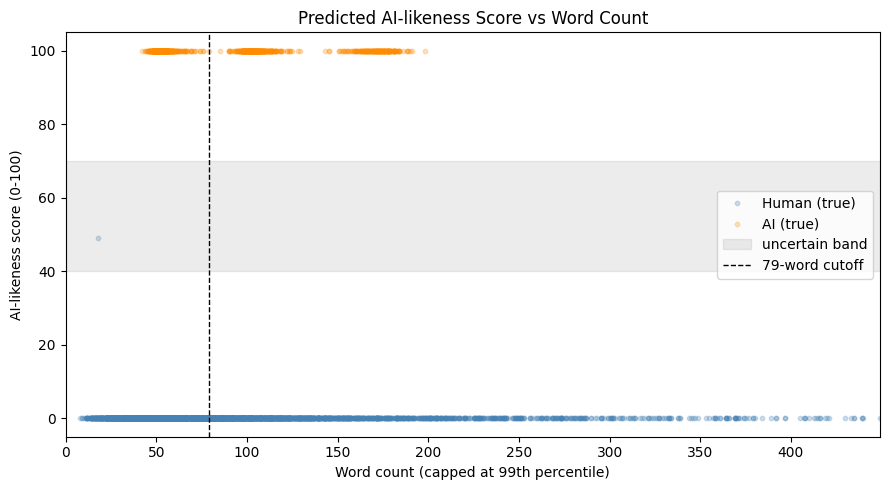

In [9]:
plt.figure(figsize=(9, 5))
for label_value, color, name in [(0, "steelblue", "Human"), (1, "darkorange", "AI")]:
    sub = test_df[test_df["true_label_binary"] == label_value]
    plt.scatter(
        sub["word_count"], sub["ai_likeness_score"],
        alpha=0.25, s=10, c=color, label=f"{name} (true)",
    )
plt.axhspan(40, 70, color="gray", alpha=0.15, label="uncertain band")
plt.axvline(79, color="black", linestyle="--", linewidth=1, label="79-word cutoff")
plt.xlim(0, np.percentile(test_df["word_count"], 99))
plt.xlabel("Word count (capped at 99th percentile)")
plt.ylabel("AI-likeness score (0-100)")
plt.title("Predicted AI-likeness Score vs Word Count")
plt.legend(loc="center right")
plt.tight_layout()
plt.show()

## 9. Misclassified examples in each subgroup

Whatever errors do show up are worth eyeballing directly. Even one or two examples can hint at the type of review that fools the model (very short complaints, neutral one-liners, polished long human reviews, etc.).

In [10]:
errors = test_df[
    test_df["true_label_binary"] != (test_df["predicted_label"] == "AI").astype(int)
].copy()

print(f"Total misclassified: {len(errors)} out of {len(test_df)}")
print()
print("Errors by subgroup:")
print(errors["length_group"].value_counts())
print()

if not errors.empty:
    show_n = min(8, len(errors))
    sample = errors.sample(n=show_n, random_state=42) if len(errors) > show_n else errors
    sample = sample.copy()
    sample["review_short"] = sample["review_text"].str.slice(0, 200) + "..."
    display(
        sample[[
            "length_group", "word_count", "true_label",
            "predicted_label", "ai_likeness_score", "review_short",
        ]].reset_index(drop=True)
    )
else:
    print("No misclassifications on the test set.")

Total misclassified: 0 out of 5185

Errors by subgroup:
Series([], Name: count, dtype: int64)

No misclassifications on the test set.


## 10. Summary

The subgroup analysis serves three purposes:

1. It directly addresses the proposal's stated evaluation plan, which called for short vs long subgroup metrics, and Milestone 2's planned next step on robustness.
2. It shows whether the calibrated random forest's strong overall metrics come from genuinely strong signal across length regimes or are propped up by easier long reviews. Closely matched short and long metrics support the former; a noticeable gap supports the latter.
3. It tests whether the uncertain band actually activates anywhere on real test data. A finding that the uncertain band only activates on short reviews would be consistent with the broader detector literature (Pudasaini et al. 2025, Erol et al. 2025), which notes that detectors typically lose confidence as text becomes shorter and less distinctive.

The numerical and visual results above let us check each of these directly. Even where short and long subgroup metrics stay matched, results should still be reported as promising rather than definitive because, as noted in Milestone 2, the synthetic AI dataset may retain residual generator artifacts that make detection easier than it would be in mixed-origin real-world data.

In [11]:
subgroup_outputs = {
    "length_threshold_words": 79,
    "metrics_df": metrics_df,
    "band_table": band_table,
    "calibration_df": calib_df,
    "errors": errors[[
        "review_text", "word_count", "length_group", "true_label",
        "predicted_label", "ai_probability", "ai_likeness_score",
    ]].reset_index(drop=True),
}

with open("subgroup_analysis_outputs.pkl", "wb") as f:
    pickle.dump(subgroup_outputs, f)

print("Saved subgroup_analysis_outputs.pkl")

Saved subgroup_analysis_outputs.pkl
